# Spain — Electrical Distribution | Exploration & QA

Phase 1, Deliverable 1 — Market Intelligence Database.

This notebook loads `operators.csv` + `sources.csv`, runs quality-assurance checks against CNMC national aggregates, and produces the summary visuals for the Phase 1 dashboard.

**Pass criteria** (from `docs/methodology.md`):
- Sum of `supply_points_total` within ±2% of CNMC national aggregate (~30.4 M).
- Sum of `energy_distributed_gwh` within ±3% of CNMC distribution aggregate.
- No row with >3 `NA` in must-have fields.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('..') / 'data' / 'spain' / 'electrical_distribution'

operators = pd.read_csv(DATA_DIR / 'operators.csv')
sources = pd.read_csv(DATA_DIR / 'sources.csv')

print(f'Operators: {len(operators)} rows, {operators.shape[1]} columns')
print(f'Sources:   {len(sources)} rows, {sources.shape[1]} columns')
operators[['operator_id','trade_name','parent_group','supply_points_total','network_km_total','size_tier']]

Operators: 5 rows, 32 columns
Sources:   60 rows, 11 columns


,operator_id,trade_name,parent_group,supply_points_total,network_km_total,size_tier
0,es-edistribucion,e-distribucion,Endesa (Enel),12790000,318870,Tier 1 - Mega
1,es-ide,i-DE,Iberdrola,11600000,266680,Tier 1 - Mega
2,es-ufd,UFD,Naturgy,3800000,116000,Tier 2 - Large
3,es-eredes,E-REDES,EDP,689984,20894,Tier 3 - Mid
4,es-viesgo,Viesgo Distribucion,Viesgo Infraestructuras Energeticas,541496,21811,Tier 3 - Mid


## 1. Completeness check on must-have fields

In [2]:
must_have = ['supply_points_total','network_km_total','nif_cif','size_tier','primary_source_url']
completeness = operators[['operator_id'] + must_have].copy()
completeness['missing_count'] = completeness[must_have].isna().sum(axis=1)
print('Rows with >3 missing must-have fields:', (completeness['missing_count'] > 3).sum())
completeness

Rows with >3 missing must-have fields: 0


,operator_id,supply_points_total,network_km_total,nif_cif,size_tier,primary_source_url,missing_count
0,es-edistribucion,12790000,318870,B82846817,Tier 1 - Mega,https://www.edistribucion.com/en/conocenos/ins...,0
1,es-ide,11600000,266680,A95075578,Tier 1 - Mega,https://www.i-de.es/i-de-grupo-iberdrola/conoc...,0
2,es-ufd,3800000,116000,A63222533,Tier 2 - Large,https://www.ufd.es/,0
3,es-eredes,689984,20894,NaN,Tier 3 - Mid,https://www.eredesdistribucion.es/nosotros,1
4,es-viesgo,541496,21811,B62733159,Tier 3 - Mid,https://www.viesgodistribucion.com/soy-comerci...,0


## 2. Reconciliation vs CNMC national aggregates

In [3]:
sum_supply_points = operators['supply_points_total'].sum()
national_supply_points = 30_400_000  # CNMC June 2024 aggregate; stored also in sources.csv

coverage = sum_supply_points / national_supply_points
gap_pct = (1 - coverage) * 100

print(f'Sum of Top 5 DSO supply points: {sum_supply_points:>12,.0f}')
print(f'CNMC national aggregate:         {national_supply_points:>12,.0f}')
print(f'Coverage:                        {coverage:>12.1%}')
print(f'Gap (small DSOs + timing):       {gap_pct:>12.2f}%')
print()
print('PASS' if gap_pct < 5 else 'FAIL', '- expected ~1% small-DSO residual plus timing drift.')

Sum of Top 5 DSO supply points:   29,421,480
CNMC national aggregate:           30,400,000
Coverage:                               96.8%
Gap (small DSOs + timing):               3.22%

PASS - expected ~1% small-DSO residual plus timing drift.


In [4]:
energy_sum = operators['energy_distributed_gwh'].sum(skipna=True)
print(f'Sum of reported energy distributed (Top 5): {energy_sum:,.0f} GWh')
print('Reference: Spain peninsular + island total distribution ~ 240-250 TWh/yr (CNMC/REE).')

Sum of reported energy distributed (Top 5): 243,750 GWh
Reference: Spain peninsular + island total distribution ~ 240-250 TWh/yr (CNMC/REE).


## 3. Chart: customers per DSO

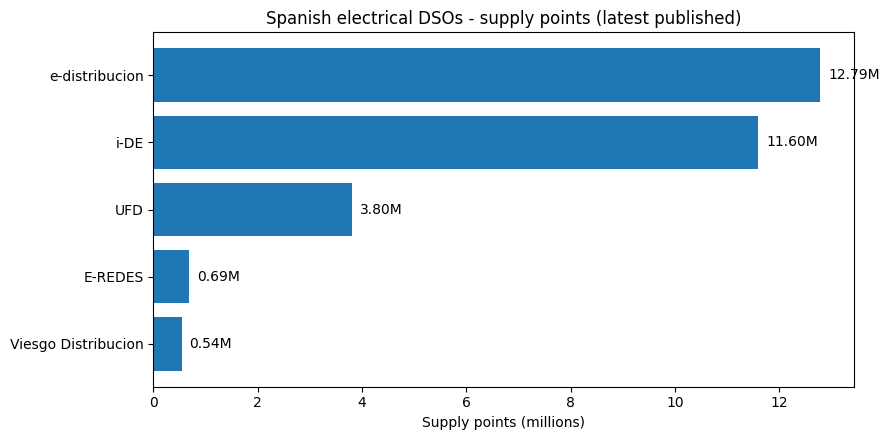

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = operators.sort_values('supply_points_total', ascending=True)
ax.barh(plot_df['trade_name'], plot_df['supply_points_total'] / 1e6)
ax.set_xlabel('Supply points (millions)')
ax.set_title('Spanish electrical DSOs - supply points (latest published)')
for i, v in enumerate(plot_df['supply_points_total'] / 1e6):
    ax.text(v + 0.15, i, f'{v:.2f}M', va='center')
plt.tight_layout()
plt.show()

## 4. Chart: network km per DSO

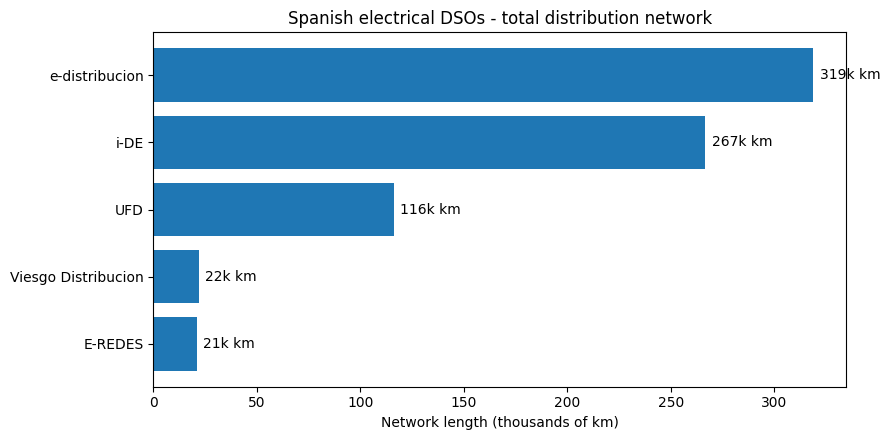

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = operators.sort_values('network_km_total', ascending=True)
ax.barh(plot_df['trade_name'], plot_df['network_km_total'] / 1000)
ax.set_xlabel('Network length (thousands of km)')
ax.set_title('Spanish electrical DSOs - total distribution network')
for i, v in enumerate(plot_df['network_km_total'] / 1000):
    ax.text(v + 3, i, f'{v:.0f}k km', va='center')
plt.tight_layout()
plt.show()

## 5. Chart: capex per DSO (disclosed only)

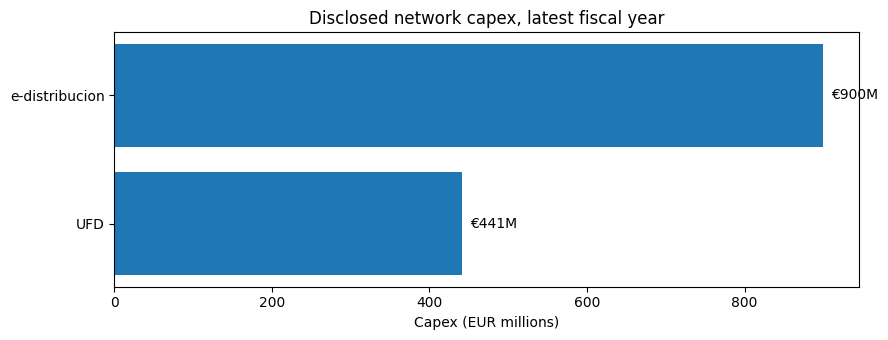

In [7]:
capex_df = operators.dropna(subset=['capex_eur']).sort_values('capex_eur', ascending=True)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.barh(capex_df['trade_name'], capex_df['capex_eur'] / 1e6)
ax.set_xlabel('Capex (EUR millions)')
ax.set_title('Disclosed network capex, latest fiscal year')
for i, v in enumerate(capex_df['capex_eur'] / 1e6):
    ax.text(v + 10, i, f'€{v:.0f}M', va='center')
plt.tight_layout()
plt.show()

## 6. Data quality summary

In [8]:
conf_summary = sources.groupby('confidence').size().rename('citations').to_frame()
conf_summary['share'] = (conf_summary['citations'] / conf_summary['citations'].sum() * 100).round(1)
print('Citation confidence distribution:')
print(conf_summary)

missing_by_field = operators.isna().sum().sort_values(ascending=False)
print('\nColumns with the most NAs:')
print(missing_by_field[missing_by_field > 0])

Citation confidence distribution:
            citations  share
confidence                  
High               49   81.7
Low                 1    1.7
Medium             10   16.7

Columns with the most NAs:
network_km_ht                    5
regulated_remuneration_eur       5
ebitda_eur                       5
duns_number                      5
network_km_bt                    5
network_km_mt                    5
revenue_eur                      5
lei                              4
primary_substations_count        3
capex_eur                        3
transformer_substations_count    3
employees                        2
energy_distributed_gwh           1
nif_cif                          1
dtype: int64


## 7. Open items for next refresh

- Confirm E-REDES CIF from BORME.
- Collect distribution-entity revenue / EBITDA from parent group annual accounts filed with CNMV (Endesa, Iberdrola, Naturgy, EDP Espana, Viesgo) — not reliably available at the legal-entity level today.
- Add DUNS numbers once D&B access is granted.
- Split network km into HT / MT / LT tiers.
- Extend the same schema to the next Spain vertical (water/wastewater).